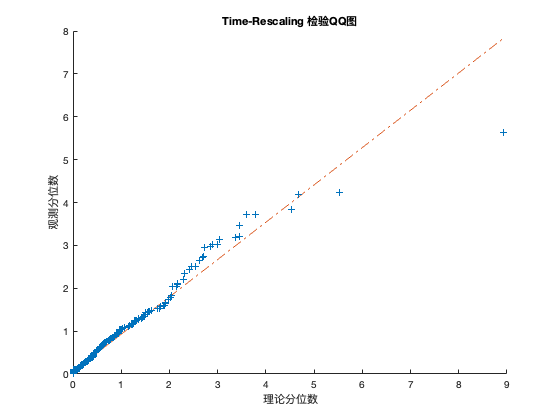

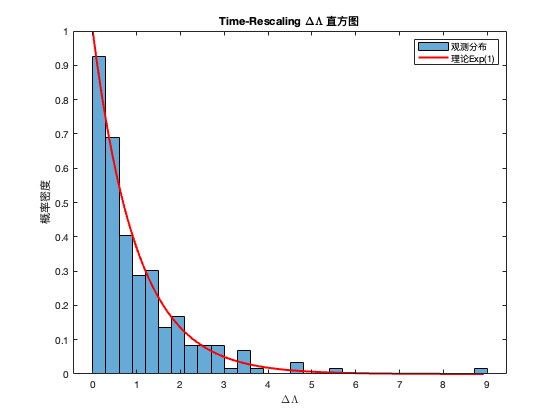

In [3]:
% 假设总时间
Tmax = 10; % 10秒

% 构造一个非恒定发放率 lambda(t)，例如：随时间震荡
dt = 0.001; % 时间分辨率1ms
tvec = 0:dt:Tmax;
lambda_t = 20 + 15*sin(2*pi*0.5*tvec); % 平均20Hz，0.5Hz正弦变化

% 模拟非齐次泊松过程：Ogata的thinning方法
spike_times = [];
t = 0;
lambda_max = max(lambda_t);
while t < Tmax
    % 在lambda_max控制下抽样等待时间
    u = rand;
    t = t - log(u)/lambda_max;
    if t >= Tmax
        break
    end
    % 接受/拒绝
    lambda_current = interp1(tvec, lambda_t, t, 'linear', 'extrap');
    if rand < lambda_current/lambda_max
        spike_times(end+1) = t; %#ok<SAGROW>
    end
end

% Time-rescaling: 计算积分Lambda(t)到每个spike
Lambda = cumtrapz(tvec, lambda_t); % λ(t)的积分
Lambda_spikes = interp1(tvec, Lambda, spike_times);

% 重新计算delta Lambda
delta_Lambda = diff([0 Lambda_spikes]);

% 理论上delta_Lambda应是标准指数分布，做QQ plot
figure;
qqplot(delta_Lambda, exprnd(1, size(delta_Lambda))); % QQ和理论指数分布比较
xlabel('理论分位数');
ylabel('观测分位数');
title('Time-Rescaling 检验QQ图');

% 附加直方图
figure;
histogram(delta_Lambda, 30, 'Normalization', 'pdf');
hold on;
x = linspace(0, max(delta_Lambda), 100);
plot(x, exp(-x), 'r', 'LineWidth', 2); % 理论指数PDF
xlabel('\Delta\Lambda');
ylabel('概率密度');
legend('观测分布','理论Exp(1)');
title('Time-Rescaling \Delta\Lambda 直方图');


In [4]:
workspace